In [ ]:
# from sahiloan_chatbot.infrastructure.monitoring.opik import configure_opik_tracing

# configure_opik_tracing()

/Users/vishnum/Library/Caches/pypoetry/virtualenvs/sahiloan-chatbot-h6twZ8gO-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-26 19:16:40.403 | DEBUG    | sahiloan_chatbot.application.chat_service.workflow.nodes:_load_intent_eval_dataset:64 - Looking for eval dataset at: /Users/vishnum/sahiloan-customer-chatbot/data/evals/intent_router.json
2026-01-26 19:16:40.405 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:_load_intent_eval_dataset:77 - Loading 25 eval queries for intent caching...
2026-01-26 19:16:51.062 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:_load_intent_eval_dataset:89 - ✅ Cached 25 intent router embeddings


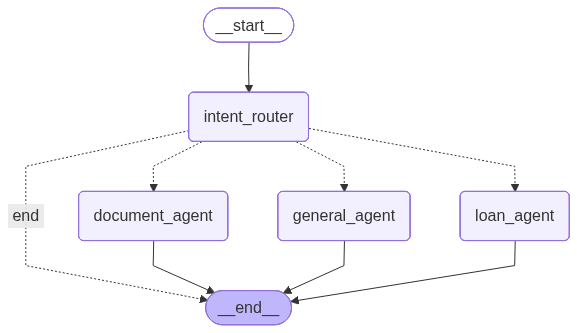

In [1]:
from sahiloan_chatbot.application.chat_service.workflow import create_chat_graph, ChatState
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage
from opik.integrations.langchain import OpikTracer
import uuid, time
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph_builder = create_chat_graph()
graph = graph_builder.compile(checkpointer)
opik_tracer = OpikTracer(graph=graph.get_graph(xray=True), project_name="sahiloan_chatbot")
graph

In [2]:
from langgraph.types import Command
from sahiloan_chatbot import logger

def get_response(user_query, thread_id=None):
    response = None
    logger.info(f"Agent Started | Query: {user_query}")
    start = time.perf_counter()

    agent_state = ChatState(messages=[HumanMessage(content=user_query)])
    
    if thread_id is None:
        thread_id = str(uuid.uuid4())[:8]
        logger.info(f"created new thread: {thread_id}")
        
    logger.info(f"Agent State: {agent_state}")
    config = {"configurable": {"thread_id": str(thread_id)}, "callbacks": [opik_tracer]}
    response = graph.invoke(agent_state, config=config)
    latency = (time.perf_counter() - start) * 1000
    logger.info(f"Agent Completed | Latency: {latency:.2f}ms")
    logger.info(f"Completed State: \n{response}")
    return response.get("messages")[-1].content

In [3]:
get_response("I need car loan instantly")

2026-01-26 19:17:07.985 | INFO     | __main__:get_response:6 - Agent Started | Query: I need car loan instantly
2026-01-26 19:17:07.991 | INFO     | __main__:get_response:13 - created new thread: e761f081
2026-01-26 19:17:07.993 | INFO     | __main__:get_response:15 - Agent State: {'messages': [HumanMessage(content='I need car loan instantly', additional_kwargs={}, response_metadata={})]}
OPIK: Started logging traces to the "sahiloan_chatbot" project at https://www.comet.com/opik/api/v1/session/redirect/projects/?trace_id=019bfa8e-e75f-7318-a910-03fb8ad4960d&path=aHR0cHM6Ly93d3cuY29tZXQuY29tL29waWsvYXBpLw==.
2026-01-26 19:17:08.006 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:152 - intent_router_started
2026-01-26 19:17:08.007 | DEBUG    | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:156 - intent_router_user_input: I need car loan instantly
2026-01-26 19:17:08.504 | DEBUG    | sahiloan_chatbot.application.chat_service.wor

"I understand that you're looking for an instant car loan. While I don't have specific information on instant loans, I recommend visiting our website or contacting our customer service team for assistance. They can guide you through the application process and help you find the best options available for your needs. If you have any other questions or need further assistance, feel free to ask!"

✅ Intent router graph compiled successfully
✅ Opik tracer initialized


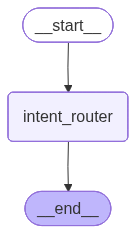

In [4]:
from sahiloan_chatbot.application.chat_service.workflow.graph import create_intent_router_graph
from sahiloan_chatbot.application.chat_service.workflow.state import ChatState
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage
from opik.integrations.langchain import OpikTracer
import uuid
import time

# Initialize memory checkpointer
checkpointer = MemorySaver()

# Create and compile the intent router graph
graph_builder = create_intent_router_graph()
intent_router_graph = graph_builder.compile(checkpointer)

# Initialize Opik tracer
opik_tracer = OpikTracer(
    graph=intent_router_graph.get_graph(xray=True), 
    project_name="sahiloan_chatbot"
)

print("✅ Intent router graph compiled successfully")
print(f"✅ Opik tracer initialized")

# Display the graph
intent_router_graph

In [ ]:
from langgraph.types import Command
from sahiloan_chatbot import logger

def get_intent_router_response(user_query, thread_id=None):
    response = None
    logger.info(f"Agent Started | Query: {user_query}")
    start = time.perf_counter()

    agent_state = ChatState(messages=[HumanMessage(content=user_query)])
    
    if thread_id is None:
        thread_id = str(uuid.uuid4())[:8]
        logger.info(f"created new thread: {thread_id}")
        
    logger.info(f"Agent State: {agent_state}")
    config = {"configurable": {"thread_id": str(thread_id)}, "callbacks": [opik_tracer]}
    response = intent_router_graph.invoke(agent_state, config=config)
    latency = (time.perf_counter() - start) * 1000
    logger.info(f"Agent Completed | Latency: {latency:.2f}ms")
    logger.info(f"Completed State: \n{response}")
    return response.get("route_to")

In [11]:
get_intent_router_response("who is shubham")

2026-01-26 19:21:12.795 | INFO     | __main__:get_intent_router_response:6 - Agent Started | Query: who is shubham
2026-01-26 19:21:12.796 | INFO     | __main__:get_intent_router_response:13 - created new thread: e13788f9
2026-01-26 19:21:12.797 | INFO     | __main__:get_intent_router_response:15 - Agent State: {'messages': [HumanMessage(content='who is shubham', additional_kwargs={}, response_metadata={})]}
2026-01-26 19:21:12.805 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:152 - intent_router_started
2026-01-26 19:21:12.805 | DEBUG    | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:156 - intent_router_user_input: who is shubham
2026-01-26 19:21:13.437 | DEBUG    | sahiloan_chatbot.application.chat_service.workflow.nodes:_find_similar_intent:142 - No semantic match | best similarity: 0.2841 (< 0.9)
2026-01-26 19:21:13.438 | DEBUG    | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:172 - No semanti

'general_agent'